In [67]:
# Import libraries required for data analysis and machine learning

import pandas as pd              # Data manipulation
import numpy as np               # Numerical operations
import seaborn as sns            # Data visualization
import matplotlib.pyplot as plt  # Plotting graphs

from sklearn.linear_model import LinearRegression, Ridge     # Regression models
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # Feature scaling & polynomial features
from sklearn.pipeline import Pipeline                        # Pipeline for ML workflow
from sklearn.model_selection import train_test_split         # Splitting data

In [68]:
# Dataset URL
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv"

# Load dataset into dataframe
df = pd.read_csv(filepath, header=None)

# Display first rows
df.head()

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [69]:
# Define column names
headers = ["age","gender","bmi","no_of_children","smoker","region","charges"]

# Assign headers to dataframe
df.columns = headers

# Display dataframe
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [70]:
# Replace missing values
df.replace("?", np.nan, inplace=True)

df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [71]:
# Check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [72]:
# Convert columns to numeric format
df["age"] = pd.to_numeric(df["age"], errors='coerce')
df["bmi"] = pd.to_numeric(df["bmi"], errors='coerce')
df["charges"] = pd.to_numeric(df["charges"], errors='coerce')

In [73]:
# Replace missing values in continuous variables with mean
df["age"] = df["age"].replace(np.nan, df["age"].mean())
df["bmi"] = df["bmi"].replace(np.nan, df["bmi"].mean())

# Replace missing categorical values with most frequent value
df["smoker"] = df["smoker"].replace(np.nan, df["smoker"].mode()[0])

In [74]:
# Verify dataset again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   float64
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 151.7+ KB


In [75]:
# Round insurance charges to 2 decimal places
df["charges"] = df["charges"].round(2)

df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19.0,1,27.900,0,1,3,16884.92
1,18.0,2,33.770,1,0,4,1725.55
2,28.0,2,33.000,3,0,4,4449.46
3,33.0,2,22.705,0,0,1,21984.47
4,32.0,2,28.880,0,0,1,3866.86


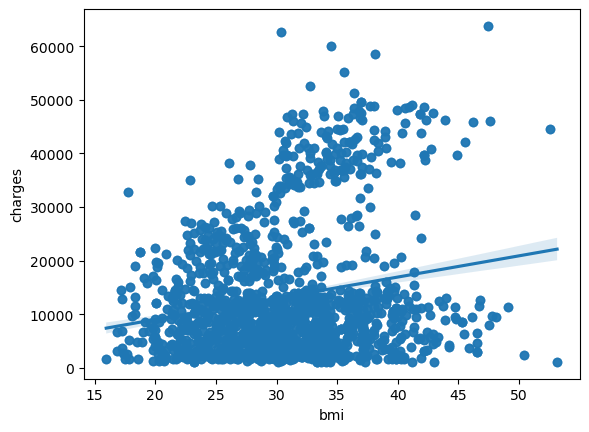

In [76]:
# Relationship between BMI and insurance charges
sns.regplot(x="bmi", y="charges", data=df)
plt.show()

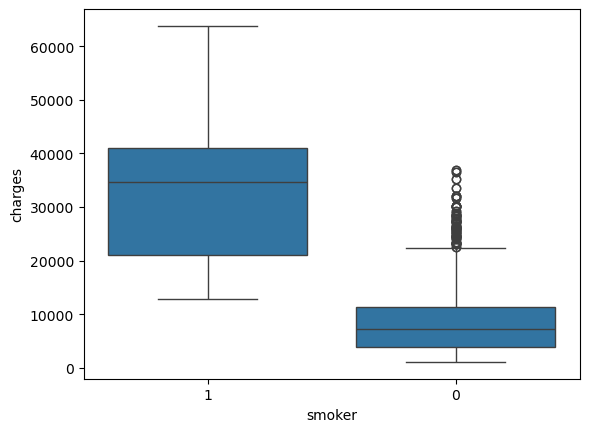

In [77]:
# Compare charges between smokers and non-smokers
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

In [78]:
# Compute correlation matrix
df.corr()

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026041,0.113045,0.037585,-0.023285,-0.007175,0.298622
gender,-0.026041,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113045,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037585,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023285,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007175,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298622,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


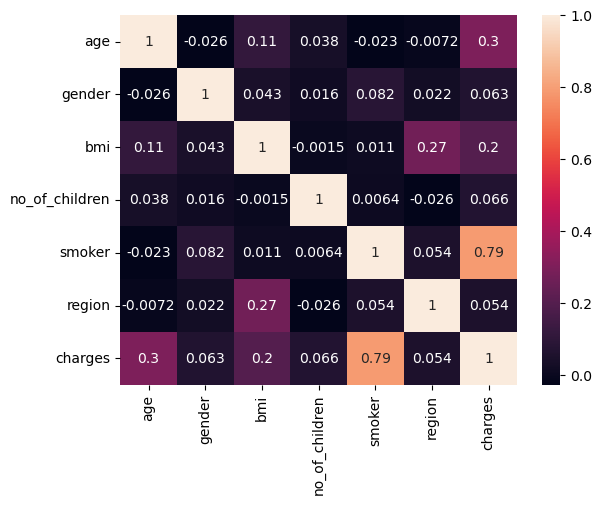

In [79]:
# Heatmap for correlation
sns.heatmap(df.corr(), annot=True)
plt.show()

In [80]:
# Independent variable
X = df[['smoker']]

# Target variable
Y = df['charges']

# Train model
lm = LinearRegression()
lm.fit(X, Y)

# Print R² score
print("R²:", lm.score(X, Y))

R²: 0.6221791733924185


In [81]:
# Use all predictors
X = df[['age','gender','bmi','no_of_children','smoker','region']]
Y = df['charges']

# Train model
lm = LinearRegression()
lm.fit(X, Y)

# Model performance
print("R²:", lm.score(X, Y))

R²: 0.7504063772187107


In [82]:
# Pipeline combining scaling, polynomial features, and regression
Input = [
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
]

pipe = Pipeline(Input)

pipe.fit(X, Y)

print("R²:", pipe.score(X, Y))

R²: 0.8452558518297514


In [83]:
# Split into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)

In [84]:
# Create Ridge regression model
RidgeModel = Ridge(alpha=0.1)

# Train model
RidgeModel.fit(X_train, Y_train)

# Test performance
print("R²:", RidgeModel.score(X_test, Y_test))

R²: 0.7235972654179473


In [85]:
# Create polynomial features
pr = PolynomialFeatures(degree=2)

# Transform training and testing data
X_train_pr = pr.fit_transform(X_train)
X_test_pr = pr.fit_transform(X_test)

# Train Ridge model
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(X_train_pr, Y_train)

# Model performance
print("R²:", RidgeModel.score(X_test_pr, Y_test))

R²: 0.8114674018509197
